In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

In [2]:
df = pd.read_csv("results.csv")

df["tp"] = df["bytes_recv"] / df["time"] / 2**20
df.loc[df["workers"]==101, "package"] = "kerchunk (original NetCDF)"
df.loc[(df["workers"]==100) & (df["package"]=="kerchunk"), "package"] = "kerchunk (repacked NetCDF)"

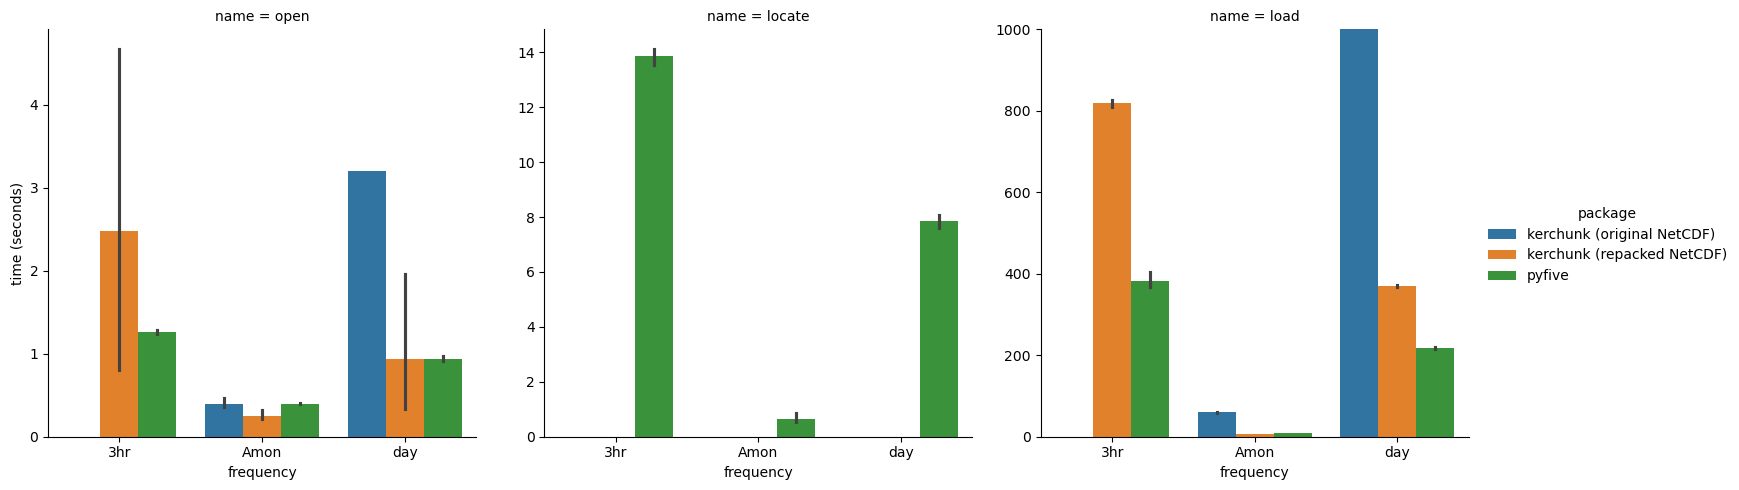

In [3]:
g = seaborn.catplot(
    df, kind="bar",
    x="frequency", y="time", col="name",
    hue="package",
    hue_order=["kerchunk (original NetCDF)", "kerchunk (repacked NetCDF)", "pyfive"],
    sharey=False)
g.axes[0,0].set_ylabel("time (seconds)")
g.axes[0,2].set(ylim=(0, 1000))
g.fig.savefig("test.pdf")